In [4]:
import sys
from pathlib import Path
PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [5]:
df = pd.read_parquet(PROJECT_ROOT / "data"/ "output1.parquet")
df612 = df[df["fX1"] > 900]
df613 = df[df["fX1"] < 600]

# Define some dfs
df612_entry = df612[(df612["isEntry"]==1) & (df612["pdgID"]==2112)]
df613_entry = df613[(df613["isEntry"]==1) & (df613["pdgID"]==2112)]

# Edeps
E_612 = np.sum(df612["fEdep"].to_numpy())
E_613 = np.sum(df613["fEdep"].to_numpy())

# Events
N_612 = len(np.unique(df612["eventID"].to_numpy()))
N_613 = len(np.unique(df613["eventID"].to_numpy()))

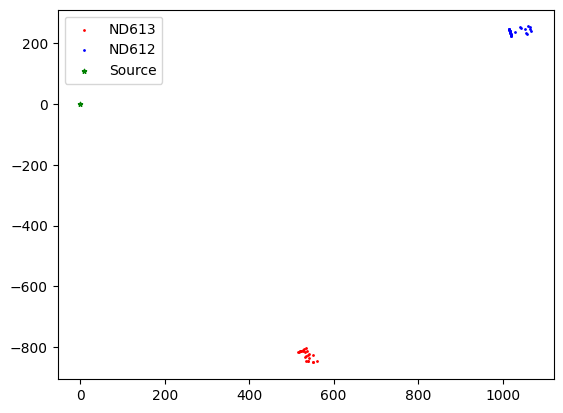

In [69]:
s = 1

fX1 = df613_entry['fX1'].to_numpy()
fY1 = df613_entry['fY1'].to_numpy()
plt.scatter(fX1, fY1, color='red', s=s, label="ND613")

fX1 = df612_entry['fX1'].to_numpy()
fY1 = df612_entry['fY1'].to_numpy()
plt.scatter(fX1, fY1, color='blue', s=s, label="ND612")

plt.scatter(0,0, label="Source", marker="*", color='green', s=10*s)
plt.legend();

In [36]:
print(f"E(612)/E(613) = {np.round(E_612,3)}/{np.round(E_613,3)} = {np.round(E_612/E_613,3)}")
print(f"N(612)/N(613) = {N_612}/{N_613} = {np.round(N_612/N_613,3)}")

E(612)/E(613) = 11.308/10.287 = 1.099
N(612)/N(613) = 28/22 = 1.273


In [33]:
# entry and edep spectra
def get_neutron_e_spectrum(df):
    this_df = df[(df["isEntry"]==1) & (df["pdgID"]==2112)]
    KEs = this_df["fK1"].to_numpy()
    return KEs

def get_event_energies(df):
    unique_events = np.unique(df["eventID"].to_numpy())
    edeps= []
    for eventid in unique_events:
        event_df = df[df["eventID"]==eventid]
        edep = np.sum(event_df["fEdep"].to_numpy())
        if edep > 0:
            edeps.append(edep)

    return edeps

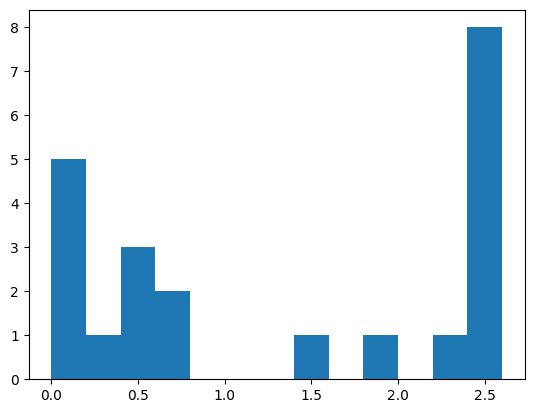

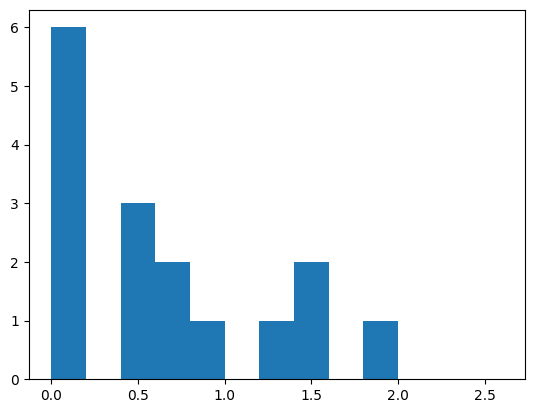

In [35]:
this_df = df613

KEs = get_neutron_e_spectrum(this_df)
bw = 0.2
KE_bins = np.arange(0, 2.6+bw, bw)
plt.hist(KEs, bins=KE_bins);
plt.show();

edeps = get_event_energies(this_df)
bw = 0.2
edep_bins = np.arange(0, 2.6+bw, bw)
plt.hist(edeps, bins=edep_bins);
plt.show();



## Direction of Entry Neutrons

In [ ]:
df612_entry

,eventID,pdgID,isEntry,fX1,fY1,fZ1,fX2,fY2,fZ2,fK1,fK2,fEdep
0,4167,2112,1,1040.304321,252.628098,-1.250863,1041.496826,244.849106,4.868104,0.486299,0.455457,0.0
4,28750,2112,1,1059.531738,255.640793,5.776178,1056.289917,247.640167,-0.112557,0.319501,0.317481,0.0
17,31021,2112,1,1019.988647,227.843430,-4.342588,1068.592041,238.700378,-4.549516,2.445000,2.445000,0.0
29,46924,2112,1,1018.154541,235.787598,-11.937984,1038.668701,240.538315,-12.178514,2.445000,2.445000,0.0
30,46924,2112,1,1065.589355,246.784790,-12.176661,1053.766357,244.965073,12.089160,2.320160,2.320160,0.0
32,80088,2112,1,1017.347900,239.281662,-8.421956,1032.844360,247.936050,0.928727,0.062086,0.037484,0.0
47,100675,2112,1,1017.339050,239.320007,5.664126,1065.816162,250.723831,5.934027,2.445000,2.445000,0.0
54,110414,2112,1,1067.764404,242.285034,-10.904984,1066.169434,241.291443,-11.246275,0.265328,0.265328,0.0
55,111593,2112,1,1058.992554,232.278839,-2.706769,1041.822144,235.280441,11.078825,1.634159,1.634159,0.0
61,124781,2112,1,1030.293823,235.870667,-12.044709,1031.410400,231.817474,-7.503382,0.081878,0.010931,0.0


In [109]:
def get_df_source_dir_vectors(df, normalise=True):
    fX1 = df['fX1'].to_numpy()
    fY1 = df['fY1'].to_numpy()
    fZ1 = df['fZ1'].to_numpy()
    fX2 = df['fX2'].to_numpy()
    fY2 = df['fY2'].to_numpy()
    fZ2 = df['fZ2'].to_numpy()

    x_dir = np.subtract(fX2, fX1)
    y_dir = np.subtract(fY2, fY1)
    z_dir = np.subtract(fZ2, fZ1)

    entry_matrix = np.array([fX1, fY1, fZ1]).T
    dir_matrix = np.array([x_dir, y_dir, z_dir]).T


    if normalise==True:
        dir_matrix_norm = []
        for vector in dir_matrix:
            vector_norm = vector / np.linalg.norm(vector)
            dir_matrix_norm.append(vector_norm)

        return entry_matrix, dir_matrix_norm
    
    else:
        return dir_matrix
    
def get_forward_and_backward_coords(entry_matrix, dir_matrix):
    forward_coords  = []
    backward_coords = []

    for idx, vector in enumerate(dir_matrix):
        entry_coord = entry_matrix[idx]
        entry_x = entry_coord[0]
        if vector[0] > 0:
            x_distance = 1850 - entry_x
            scale_factor = x_distance/vector[0]
            source_coord = np.add(entry_coord, vector * scale_factor)
            backward_coords.append(source_coord)
        else:
            x_distance = -entry_x
            scale_factor = x_distance/vector[0]
            source_coord =  np.add(entry_coord, vector * scale_factor)
            forward_coords.append(source_coord)

    return np.array(forward_coords), np.array(backward_coords)


In [131]:
entry_matrix, dir_matrix = get_df_source_dir_vectors(df613_entry)
coords = get_forward_and_backward_coords(entry_matrix, dir_matrix)
forward_coords = coords[0]
backward_coords = coords[1]

7 15


(-2500.0, 2500.0)

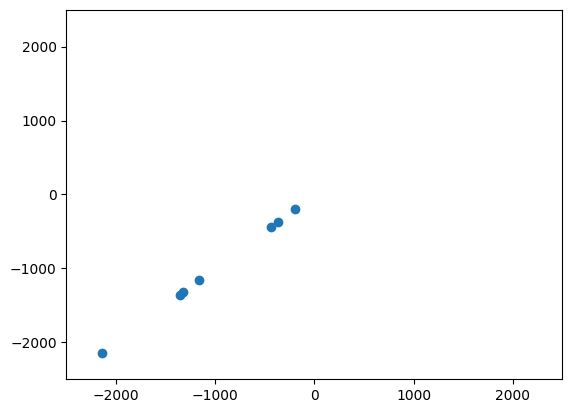

In [132]:
ys = forward_coords[:,1]
zs = forward_coords[:,1]
print(len(forward_coords), len(backward_coords))
plt.scatter(ys, zs)
plt.xlim(-2500, 2500)
plt.ylim(-2500, 2500)